# Differential Equations

We begin with a linear first-order differential equation, typically written as:

:::{math}
:enumerated: false
\dot{x}(t) = \frac{dx(t)}{dt} = a x(t) + b(t)
:::

* The term $a x(t)$ is the **homogeneous part**
* The term $b(t)$ is the **nonhomogeneous part**

---

## Solving First-Order Differential Equations

A solution describes the time path ${x(t)}$ from some initial point $t(0)$ to some future time $t(\tau)$, as a function of:

* time $t$
* the forcing term $b(t)$
* the initial value $x(0)$

---

### Case: Constant $b$

Consider:

:::{math}
:enumerated: false
\dot{x}(t) = a x(t) + b
:::

---

### Steady State

At steady state:

:::{math}
:enumerated: false
\dot{x}(t) = 0
:::

So:

:::{math}
:enumerated: false
a x + b = 0
\quad \Rightarrow \quad
x^* = -\frac{b}{a}
:::

---

### Homogeneous Equation

To solve the full equation, we first solve the homogeneous part:

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a x(t)
:::

The solution is:

:::{math}
:enumerated: false
x(t) = C e^{a t}
:::

---

### Verification

Differentiate:

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a C e^{a t} = a x(t)
:::

✔️ Verified.

---

### Definite Solution

Given an initial condition $x(0)$:

:::{math}
:enumerated: false
x(0) = C e^{0} = C
:::

Thus:

:::{math}
:enumerated: false
x(t) = x(0) e^{a t}
:::

---

## Stability

The behavior of $x(t)$ depends on $a$:

* If $a < 0$:
  → $x(t) \to 0$ as $t \to \infty$ (**stable**)

* If $a > 0$:
  → $x(t) \to \infty$ or $-\infty$ (**unstable**)

---

## General Solution (Constant Term)

Consider again:

:::{math}
:enumerated: false
\dot{x}(t) = a x(t) + b
:::

A solution takes the form:

:::{math}
:enumerated: false
x(t) = K e^{a t} - \frac{b}{a}
:::

---

### Definite Solution

Given $x(0)$:

:::{math}
:enumerated: false
x(0) = K - \frac{b}{a}
\quad \Rightarrow \quad
K = x(0) + \frac{b}{a}
:::

Thus:

:::{math}
:enumerated: false
x(t) = \left(x(0) + \frac{b}{a}\right)e^{a t} - \frac{b}{a}
:::

---

### Special Case

If $x(0) = x^* = -\frac{b}{a}$:

:::{math}
:enumerated: false
x(t) = x^*
\quad \text{for all } t
:::

---

## Stability Conditions (with Constant Term)

* If $a < 0$:
  → system converges to $x^* = -\frac{b}{a}$ (**stable**)

* If $a > 0$:
  → system diverges (**unstable**)

---

## Numerical Example (Stable Case)

Consider:

:::{math}
:enumerated: false
\dot{u}(t) = -\frac{1}{2} u(t) + 2
:::

with initial condition:

:::{math}
:enumerated: false
u(0) = 1
:::

---

### Step 1: Steady State

:::{math}
:enumerated: false
0 = -\frac{1}{2}u + 2
\quad \Rightarrow \quad
u^* = 4
:::

---

### Step 2: Solution

:::{math}
:enumerated: false
u(t) = \left(u(0) + \frac{2}{1/2}\right)e^{-t/2} - \frac{2}{-1/2}
:::

Simplify:

:::{math}
:enumerated: false
u(t) = -3 e^{-t/2} + 4
:::

---

### Interpretation

* $u(t) \to 4$ as $t \to \infty$
* Since $a = -\frac{1}{2} < 0$, the system is **stable**


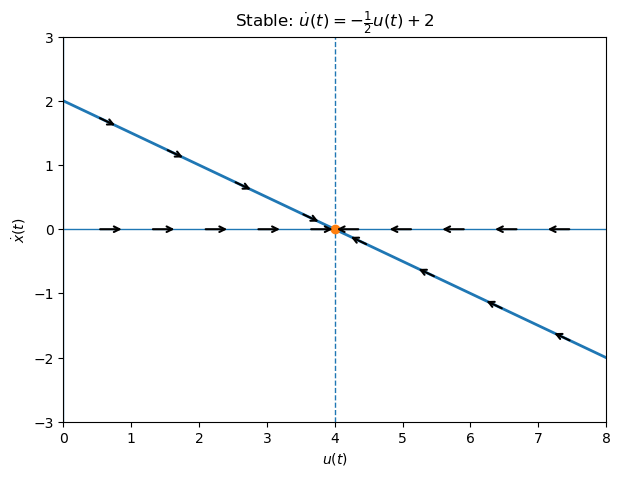

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def phase_diagram(f, x_range, x_star, title, x_label):
    x = np.linspace(x_range[0], x_range[1], 400)
    x_dot = f(x)

    fig, ax = plt.subplots(figsize=(7, 5))

    # Axes
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    # Curve
    ax.plot(x, x_dot, linewidth=2)

    # Steady state
    ax.axvline(x_star, linestyle='--', linewidth=1)
    ax.plot(x_star, 0, 'o')

    # -----------------------------
    # (1) Arrows ON the curve
    # -----------------------------
    for xi in np.linspace(x_range[0]+0.5, x_range[1]-0.5, 8):
        yi = f(xi)
        slope = (f(xi + 0.01) - yi) / 0.01  # numerical slope

        direction = np.sign(f(xi))  # sign determines motion

        dx = 0.3 * direction
        dy = slope * dx

        ax.annotate(
            '',
            xy=(xi + dx, yi + dy),
            xytext=(xi, yi),
            arrowprops=dict(arrowstyle='->', lw=1.5)
        )

    # -----------------------------
    # (2) Horizontal arrows (phase line)
    # -----------------------------
    for xi in np.linspace(x_range[0]+0.5, x_range[1]-0.5, 10):
        direction = np.sign(f(xi))
        dx = 0.4 * direction

        ax.annotate(
            '',
            xy=(xi + dx, 0),
            xytext=(xi, 0),
            arrowprops=dict(arrowstyle='->', lw=1.5)
        )

    # Labels
    ax.set_xlabel(x_label)
    ax.set_ylabel(r'$\dot{x}(t)$')
    ax.set_title(title)

    ax.set_xlim(x_range)
    ax.set_ylim(min(x_dot)-1, max(x_dot)+1)
    ax.grid(False)

    plt.show()


# -----------------------------
# Stable case: u_dot = -1/2 u + 2
# -----------------------------
f1 = lambda u: -0.5*u + 2
phase_diagram(
    f=f1,
    x_range=(0, 8),
    x_star=4,
    title=r'Stable: $\dot{u}(t) = -\frac{1}{2}u(t) + 2$',
    x_label=r'$u(t)$'
)

## Numerical Example (Unstable Case)

Consider:

:::{math}
:enumerated: false
\dot{v}(t) = 2 v(t) - 4
:::

with:

:::{math}
:enumerated: false
v(0) = 1
:::

---

### Step 1: Steady State

:::{math}
:enumerated: false
0 = 2v - 4
\quad \Rightarrow \quad
v^* = 2
:::

---

### Step 2: Solution

:::{math}
:enumerated: false
v(t) = \left(v(0) - 2\right)e^{2t} + 2
:::

Simplify:

:::{math}
:enumerated: false
v(t) = -e^{2t} + 2
:::

---

### Interpretation

* As $t \to \infty$, $v(t) \to -\infty$

* Since $a > 0$, the system is **unstable**

* Only if $v(0) = 2$:

:::{math}
:enumerated: false
v(t) = 2 \quad \forall t
:::

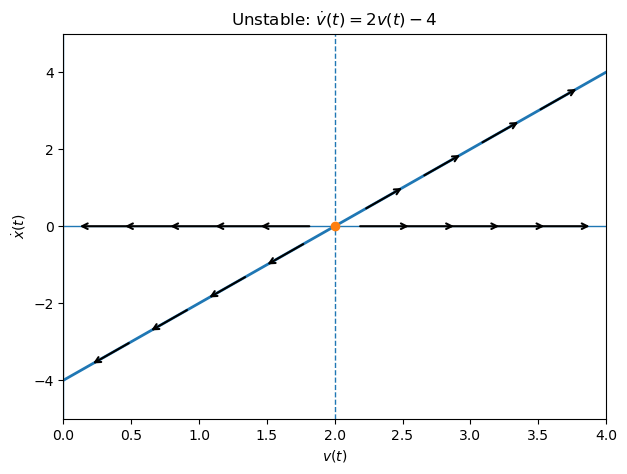

In [11]:
# -----------------------------
# Unstable case: v_dot = 2v - 4
# -----------------------------
f2 = lambda v: 2*v - 4
phase_diagram(
    f=f2,
    x_range=(0, 4),
    x_star=2,
    title=r'Unstable: $\dot{v}(t) = 2v(t) - 4$',
    x_label=r'$v(t)$'
)

## Solving First-Order Differential Equations by Integration

Let’s start with the homogeneous case

:::{math}
:enumerated: false
\dot{x}(t) = a x(t)
:::

and assuming we know at some point in time $s$ the value $x(s)$.

---

Rearranging a little and multiplying each side by $ds$ gives

:::{math}
:enumerated: false
\frac{dx(s)}{x(s)} = a , ds
:::

---

Take the definite integral of both sides evaluated from $0$ to $t$

:::{math}
:enumerated: false
\int_{0}^{t} \frac{1}{x(s)} , dx(s) = \int_{0}^{t} a , ds
:::

---

and assuming that $x(s) > 0$ gives

:::{math}
:enumerated: false
\ln(x(t)) - \ln(x(0)) = a t - a \cdot 0 = a t
:::

---

Adding $\ln(x(0))$ to each side and taking exponentials gives

:::{math}
:enumerated: false
e^{\ln(x(t))} = e^{\ln(x(0)) + a t}
:::

---

Or

:::{math}
:enumerated: false
x(t) = x(0) e^{a t}
:::

(as before).

---

## Case with Constant Term

What if we have a constant term as in equation (1) above, also written as

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a x(t) + b
:::

---

Consider some moment in time $s$ and multiply each side by $ds$:

:::{math}
:enumerated: false
dx(s) = a x(s) , ds + b , ds
:::

---

Multiplying again each side by $e^{-as}$ and rearranging gives

:::{math}
:enumerated: false
e^{-as} dx(s) - a x(s)e^{-as} ds = b e^{-as} ds
:::

---

Looks threatening doesn’t it? Not really. The left-hand side simply reduces to

:::{math}
:enumerated: false
d\big(x(s)e^{-as}\big)
:::

---

Hence we can write

:::{math}
:enumerated: false
d\big(x(s)e^{-as}\big) = b e^{-as} ds
:::

---

Taking the definite integral as before

:::{math}
:enumerated: false
\int_{0}^{t} d\big(x(s)e^{-as}\big) = \int_{0}^{t} b e^{-as} ds
:::

---

### Left-hand side (LHS)

:::{math}
:enumerated: false
x(t)e^{-at} - x(0)
:::

---

### Right-hand side (RHS)

:::{math}
:enumerated: false
\int_{0}^{t} b e^{-as} ds = \frac{b}{a}\left(1 - e^{-at}\right)
:::

---

Combining the LHS and RHS gives

:::{math}
:enumerated: false
x(t)e^{-at} - x(0) = \frac{b}{a}\left(1 - e^{-at}\right)
:::

---

Multiplying each side by $e^{at}$ and rearranging gives

:::{math}
:enumerated: false
x(t) = x(0)e^{at} + \frac{b}{a}\left(e^{at} - 1\right)
:::

---

Or

:::{math}
:enumerated: false
x(t) = \left(x(0) + \frac{b}{a}\right)e^{at} - \frac{b}{a}
:::

(as before).

---

## More General Case: Time-Varying $b(t)$

What about the more general case when we have $b(t)$ instead of just $b$? That is,

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a x(t) + b(t)
:::

---

As before, multiply by $ds$ and $e^{-as}$ to get

:::{math}
:enumerated: false
e^{-as} dx(s) - a x(s)e^{-as} ds = b(s)e^{-as} ds
:::

---

The treatment of the LHS is the same as before, so we have

:::{math}
:enumerated: false
d\big(x(s)e^{-as}\big) = b(s)e^{-as} ds
:::

---

Taking integrals gives

:::{math}
:enumerated: false
x(t)e^{-at} - x(0) = \int_{0}^{t} b(s)e^{-as} ds
:::

---

Multiplying each side by $e^{at}$ and rearranging gives

:::{math}
:enumerated: false
x(t) = x(0)e^{at} + \int_{0}^{t} b(s)e^{a(t-s)} ds
:::

---

This is known as the **backward solution**, because $x(t)$ depends on past and present values of $b(s)$.

---

## Interpretation

* The term

  :::{math}
  :enumerated: false
  x(0)e^{at}
  :::

  captures the effect of the initial value over time.

---

* The term

  :::{math}
  :enumerated: false
  \int_{0}^{t} b(s)e^{a(t-s)} ds
  :::

  reflects the discounted accumulation of past values of $b(s)$.

---

* If $a < 0$, the effect of the initial value dies out over time.

* If $a > 0$, the initial value grows over time.

---

## Infinite Horizon Case

When the relevant period extends infinitely into the past and $a < 0$, and assuming $b(s)$ is bounded:

:::{math}
:enumerated: false
x(t) = \int_{-\infty}^{t} b(s)e^{a(t-s)} ds
:::

---

## Forward Solution

Although not derived here, the forward solution is

:::{math}
:enumerated: false
x(t) = - \int_{t}^{\infty} b(s)e^{-a(s-t)} ds
:::